<a href="https://colab.research.google.com/github/Srinjoy-ghosh-IITJ/ECG-Signal-Analysis-with-Machine-Learning-/blob/main/ECG_ProtocolA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  ECG Signal Analysis with Machine Learning
**Project :** ECG Signal Analysis with Machine Learning
**Author  :** Srinjoy Ghosh | Roll: M25AI1054 | IIT Jodhpur
**Dataset :** MIT-BIH Arrhythmia Database (PhysioNet)
**Models  :** SVM | CNN | CNN-LSTM (same 10-beat input)
**Split   :** 30 records training | 18 records testing (patient-independent)

---
| Item | Detail |
|---|---|
| Training | 30 patient records |
| Testing | 18 patient records (completely unseen) |
| Input | 10 consecutive beats for ALL 3 models |
| Plots | 14 plots |
| Report | HR, RR, PR, QRS, QT, QTc, RV5, SV1, PQRSTU, ST, Diagnosis |

In [ ]:
# STEP 0 — Install packages
!pip install wfdb neurokit2 tensorflow scikit-learn imbalanced-learn matplotlib seaborn psutil -q
print('All packages installed')

All packages installed


In [ ]:
# STEP 1 — Import all libraries
import numpy as np
import pandas as pd
import wfdb
import neurokit2 as nk
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc
import psutil
from collections import Counter
from sklearn.utils import shuffle
warnings.filterwarnings('ignore')

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, auc,
    classification_report
)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, LSTM, Dense, Dropout,
    BatchNormalization, Flatten, Bidirectional,
    TimeDistributed, Input
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)
print('All libraries loaded successfully')

All libraries loaded successfully


In [ ]:
# STEP 1b — Check GPU
print('TensorFlow version:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print('GPU WORKING:', gpus)
    print('GPU name    :', tf.test.gpu_device_name())
    print('Training will be 5-10x faster')
else:
    print('GPU NOT found — using CPU')
    print('Enable: Runtime -> Change runtime type -> T4 GPU -> Save -> Restart')

TensorFlow version: 2.19.0
GPU WORKING: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU name    : /device:GPU:0
Training will be 5-10x faster


In [ ]:
# STEP 2 — Configuration
SAMPLING_RATE = 360
BEAT_WINDOW   = 150
SEQ_LEN       = 10
EPOCHS        = 20
BATCH_SIZE    = 32

# CHANGE THIS to generate report for any patient
TEST_RECORD = '231'   # try: '117','119','209','231','232','233'

LABEL_MAP = {'N':0, 'V':1, 'A':2, 'L':3, 'R':4}

CLASS_NAMES = {
    0: 'Normal ECG',
    1: 'Ventricular Arrhythmia',
    2: 'Atrial Premature Beat',
    3: 'Left Bundle Branch Block',
    4: 'Right Bundle Branch Block'
}

ARRHYTHMIA_INFO = {
    0: 'Normal sinus rhythm — SA node fires regularly at 60-100 bpm',
    1: 'Ventricle fires early — wide bizarre QRS, no P-wave',
    2: 'Atria fires early — narrow QRS, abnormal P-wave',
    3: 'Left bundle blocked — wide QRS >120ms, notched R in V5/V6',
    4: 'Right bundle blocked — wide QRS >120ms, RSR pattern in V1'
}

TRAIN_RECORDS = [
    '100','101','102','103','104',
    '105','106','107','108','109',
    '111','112','113','114','115',
    '116','117','118','119','121',
    '122','123','124','200','201',
    '202','203','205','207','208'
]

TEST_RECORDS_LIST = [
    '209','210','212','213','214',
    '215','217','219','220','221',
    '222','223','228','230','231',
    '232','233','234'
]

COLORS = ['seagreen','tomato','royalblue','darkorange','purple']

print('Project       : ECG Signal Analysis with Machine Learning')
print(f'Train records : {len(TRAIN_RECORDS)} patients')
print(f'Test records  : {len(TEST_RECORDS_LIST)} patients (unseen)')
print(f'Test record   : {TEST_RECORD}')
print(f'Input         : {SEQ_LEN} consecutive beats per model')
print()
for k,v in CLASS_NAMES.items():
    print(f'  [{k}] {v}')

Project       : ECG Signal Analysis with Machine Learning
Train records : 30 patients
Test records  : 18 patients (unseen)
Test record   : 231
Input         : 10 consecutive beats per model

  [0] Normal ECG
  [1] Ventricular Arrhythmia
  [2] Atrial Premature Beat
  [3] Left Bundle Branch Block
  [4] Right Bundle Branch Block


Loading sample beats for each arrhythmia type...
  Class 0 (Normal ECG): Found
  Class 1 (Ventricular Arrhythmia): Found
  Class 2 (Atrial Premature Beat): Found
  Class 3 (Left Bundle Branch Block): Found
  Class 4 (Right Bundle Branch Block): Found


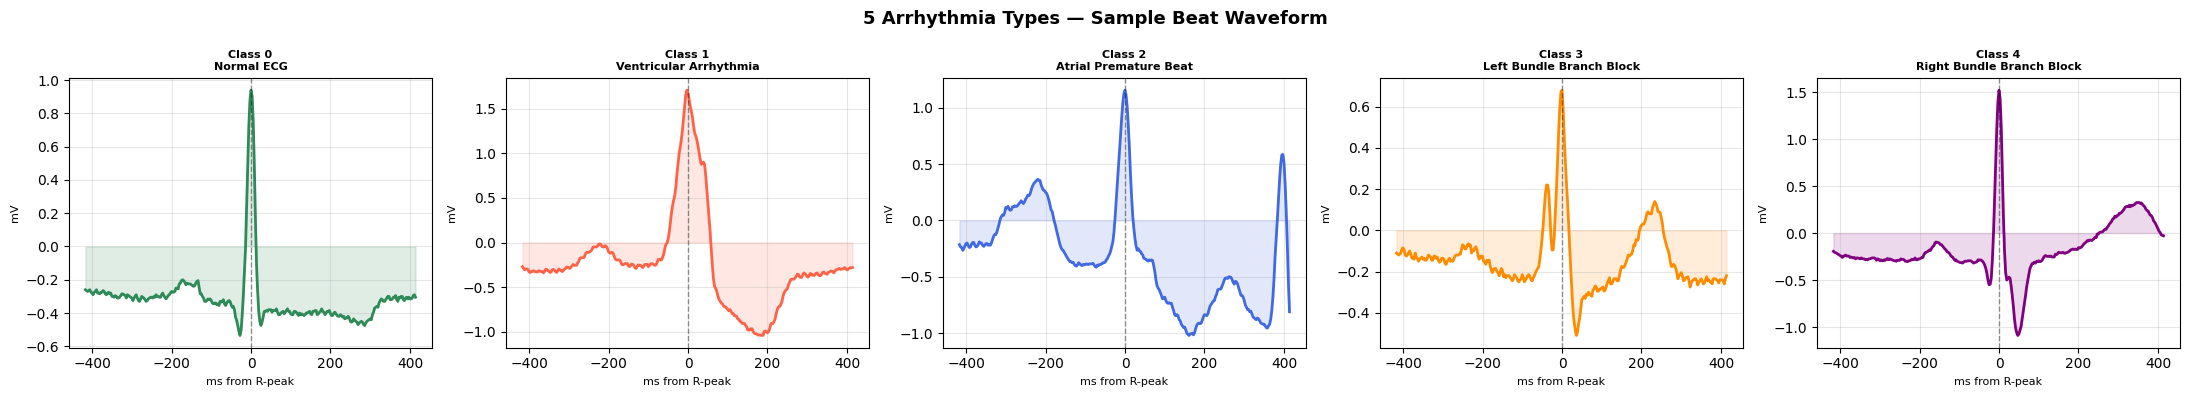

Arrhythmia waveforms saved


In [ ]:
# STEP 3 — Visualise 5 arrhythmia types
CLASS_SOURCE = {0:'100', 1:'208', 2:'202', 3:'111', 4:'231'}
CLASS_SYM    = {0:'N',   1:'V',   2:'A',   3:'L',   4:'R'}
examples     = {}

print('Loading sample beats for each arrhythmia type...')
for cls_id, rec in CLASS_SOURCE.items():
    try:
        rec_obj = wfdb.rdrecord(rec, pn_dir='mitdb')
        ann_obj = wfdb.rdann(rec, 'atr', pn_dir='mitdb')
        sig     = rec_obj.p_signal[:,0]
        _, inf  = nk.ecg_process(sig, sampling_rate=SAMPLING_RATE)
        rp      = inf['ECG_R_Peaks']
        a_s     = np.array(ann_obj.sample)
        a_y     = ann_obj.symbol
        for r in rp:
            if r-BEAT_WINDOW > 0 and r+BEAT_WINDOW < len(sig):
                diffs = np.abs(a_s - r)
                near  = np.argmin(diffs)
                if diffs[near] <= 2 and a_y[near] == CLASS_SYM[cls_id]:
                    examples[cls_id] = sig[r-BEAT_WINDOW:r+BEAT_WINDOW]
                    break
    except Exception as e:
        print(f'  Class {cls_id}: {e}')

for cls_id in range(5):
    print(f'  Class {cls_id} ({CLASS_NAMES[cls_id]}): {"Found" if cls_id in examples else "NOT FOUND"}')

beat_ms = np.arange(-BEAT_WINDOW, BEAT_WINDOW) / SAMPLING_RATE * 1000
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle('5 Arrhythmia Types — Sample Beat Waveform', fontsize=13, fontweight='bold')
for cls_id in range(5):
    ax = axes[cls_id]
    if cls_id in examples:
        ax.plot(beat_ms, examples[cls_id], color=COLORS[cls_id], lw=2)
        ax.fill_between(beat_ms, examples[cls_id], alpha=0.15, color=COLORS[cls_id])
        ax.axvline(0, color='black', ls='--', alpha=0.4, lw=1)
    ax.set_title(f'Class {cls_id}\n{CLASS_NAMES[cls_id]}', fontweight='bold', fontsize=8)
    ax.set_xlabel('ms from R-peak', fontsize=8)
    ax.set_ylabel('mV', fontsize=8)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('arrhythmia_types.png', dpi=150, bbox_inches='tight')
plt.show()
print('Arrhythmia waveforms saved')

Loading TRAINING data from 30 records...
Training sequences: 46,786  shape=(46786, 10, 300)
Class distribution: {np.int32(0): np.int64(37423), np.int32(1): np.int64(1324), np.int32(2): np.int64(89), np.int32(3): np.int64(4445), np.int32(4): np.int64(3505)}


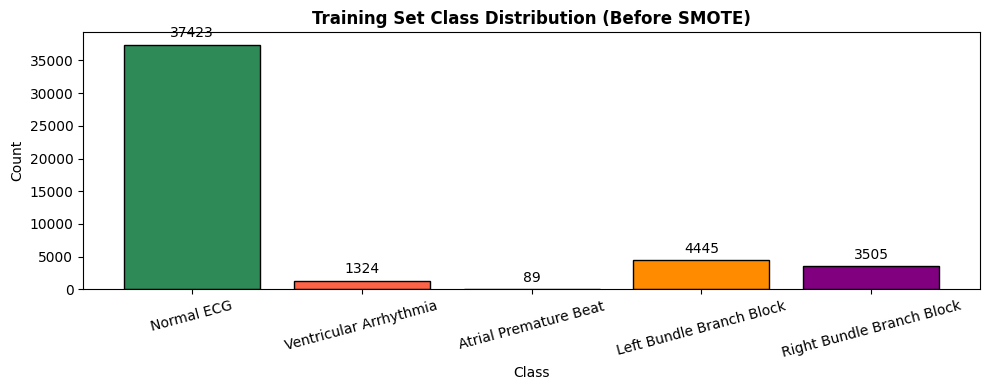

In [ ]:
# STEP 4 — Load TRAINING data (30 records)
train_seqs, train_labels = [], []
print(f'Loading TRAINING data from {len(TRAIN_RECORDS)} records...')

half = SEQ_LEN // 2
for rec in TRAIN_RECORDS:
    try:
        record = wfdb.rdrecord(rec, pn_dir='mitdb')
        ann    = wfdb.rdann(rec, 'atr', pn_dir='mitdb')
        signal = record.p_signal[:,0]
        _, info = nk.ecg_process(signal, sampling_rate=SAMPLING_RATE)
        r_peaks = info['ECG_R_Peaks']
        ann_s = np.array(ann.sample)
        ann_y = ann.symbol
        for i in range(half, len(r_peaks)-half):
            seq, valid = [], True
            for j in range(i-half, i+half):
                r = r_peaks[j]
                if r-BEAT_WINDOW > 0 and r+BEAT_WINDOW < len(signal):
                    seq.append(signal[r-BEAT_WINDOW:r+BEAT_WINDOW])
                else:
                    valid = False; break
            if not valid or len(seq) != SEQ_LEN:
                continue
            diffs = np.abs(ann_s - r_peaks[i])
            near  = np.argmin(diffs)
            if diffs[near] <= 2 and ann_y[near] in LABEL_MAP:
                train_seqs.append(seq)
                train_labels.append(LABEL_MAP[ann_y[near]])
    except Exception as e:
        print(f'  Skipped {rec}: {e}')

X_train_raw = np.array(train_seqs,   dtype=np.float32)
y_train_raw = np.array(train_labels, dtype=np.int32)
print(f'Training sequences: {len(X_train_raw):,}  shape={X_train_raw.shape}')
print(f'Class distribution: {dict(zip(*np.unique(y_train_raw, return_counts=True)))}')

fig, ax = plt.subplots(figsize=(10,4))
cc = dict(zip(*np.unique(y_train_raw, return_counts=True)))
bars = ax.bar([CLASS_NAMES[k] for k in sorted(cc)],
              [cc[k] for k in sorted(cc)],
              color=COLORS, edgecolor='black')
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_title('Training Set Class Distribution (Before SMOTE)', fontweight='bold')
ax.set_xlabel('Class'); ax.set_ylabel('Count')
plt.xticks(rotation=15); plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# STEP 5 — Load TEST data (18 unseen records)
test_seqs, test_labels = [], []
print(f'Loading TEST data from {len(TEST_RECORDS_LIST)} unseen records...')

for rec in TEST_RECORDS_LIST:
    try:
        record = wfdb.rdrecord(rec, pn_dir='mitdb')
        ann    = wfdb.rdann(rec, 'atr', pn_dir='mitdb')
        signal = record.p_signal[:,0]
        _, info = nk.ecg_process(signal, sampling_rate=SAMPLING_RATE)
        r_peaks = info['ECG_R_Peaks']
        ann_s = np.array(ann.sample)
        ann_y = ann.symbol
        for i in range(half, len(r_peaks)-half):
            seq, valid = [], True
            for j in range(i-half, i+half):
                r = r_peaks[j]
                if r-BEAT_WINDOW > 0 and r+BEAT_WINDOW < len(signal):
                    seq.append(signal[r-BEAT_WINDOW:r+BEAT_WINDOW])
                else:
                    valid = False; break
            if not valid or len(seq) != SEQ_LEN:
                continue
            diffs = np.abs(ann_s - r_peaks[i])
            near  = np.argmin(diffs)
            if diffs[near] <= 2 and ann_y[near] in LABEL_MAP:
                test_seqs.append(seq)
                test_labels.append(LABEL_MAP[ann_y[near]])
    except Exception as e:
        print(f'  Skipped {rec}: {e}')

X_test_raw = np.array(test_seqs,   dtype=np.float32)
y_test     = np.array(test_labels, dtype=np.int32)
print(f'Test sequences: {len(X_test_raw):,}  shape={X_test_raw.shape}')
print(f'Class distribution: {dict(zip(*np.unique(y_test, return_counts=True)))}')
print()
print(f'Train: {len(X_train_raw):,} sequences from {len(TRAIN_RECORDS)} patients')
print(f'Test : {len(X_test_raw):,} sequences from {len(TEST_RECORDS_LIST)} unseen patients')

Loading TEST data from 18 unseen records...
Test sequences: 37,877  shape=(37877, 10, 300)
Class distribution: {np.int32(0): np.int64(29211), np.int32(1): np.int64(1605), np.int32(2): np.int64(1898), np.int32(3): np.int64(1825), np.int32(4): np.int64(3338)}

Train: 46,786 sequences from 30 patients
Test : 37,877 sequences from 18 unseen patients


Normalised — train: (46786, 10, 300) | test: (37877, 10, 300)
After SMOTE : 187,115 samples
After limit : 20,000 samples (4000 per class)
After shuffle — first 20 labels: [2 0 2 0 3 2 2 0 4 2 0 1 4 4 3 1 4 4 2 0]
Class counts: {np.int32(0): np.int64(4000), np.int32(1): np.int64(4000), np.int32(2): np.int64(4000), np.int32(3): np.int64(4000), np.int32(4): np.int64(4000)}


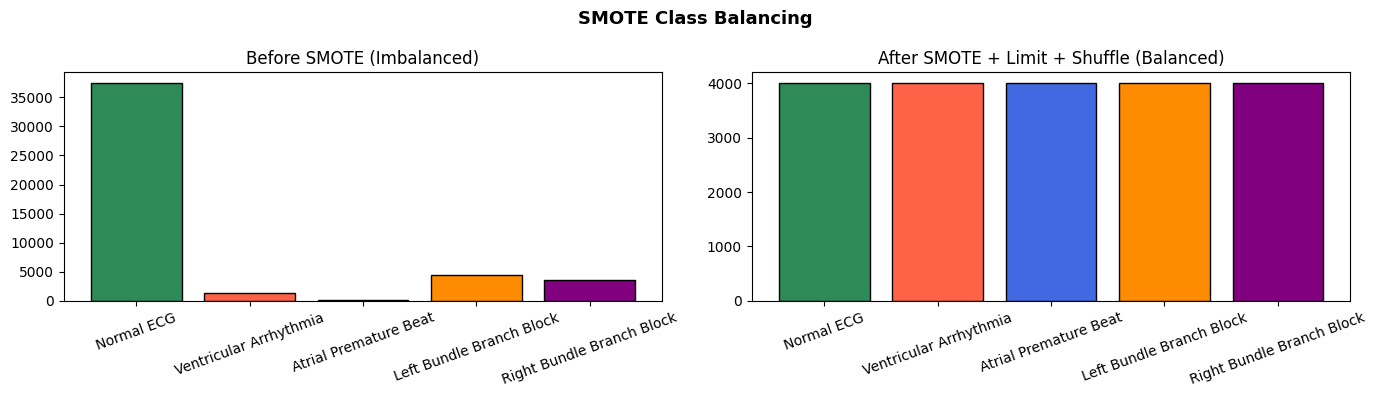


SVM   train: (20000, 3000)  | test: (37877, 3000)
CNN   train: (20000, 3000, 1) | test: (37877, 3000, 1)
LSTM  train: (20000, 10, 300, 1) | test: (37877, 10, 300, 1)

RAM freed — now: 4.8 / 13.6 GB
All 3 model inputs ready — safe to train


In [ ]:
# STEP 6 — Normalise + SMOTE + Shuffle + Reshape + RAM Release
# All in correct order in ONE cell — avoids all undefined variable errors

# 6a — Normalise (fit on train only — no data leakage)
scaler    = StandardScaler()
X_tr_flat = X_train_raw.reshape(-1, 300)
X_te_flat = X_test_raw.reshape(-1, 300)
X_tr_flat = scaler.fit_transform(X_tr_flat)
X_te_flat = scaler.transform(X_te_flat)
X_train_n = X_tr_flat.reshape(-1, SEQ_LEN, 300)
X_test_n  = X_te_flat.reshape(-1, SEQ_LEN, 300)
print(f'Normalised — train: {X_train_n.shape} | test: {X_test_n.shape}')

# 6b — SMOTE on train only
X_flat_s = X_train_n.reshape(len(X_train_n), -1)
smote    = SMOTE(random_state=42)
X_b, y_b = smote.fit_resample(X_flat_s, y_train_raw)
print(f'After SMOTE : {len(X_b):,} samples')

# 6c — Limit to 4000 per class (saves RAM)
rus      = RandomUnderSampler(
    sampling_strategy={0:4000,1:4000,2:4000,3:4000,4:4000},
    random_state=42)
X_b, y_b = rus.fit_resample(X_b, y_b)
X_train_b = X_b.reshape(-1, SEQ_LEN, 300)
print(f'After limit : {len(X_train_b):,} samples (4000 per class)')

# 6d — SHUFFLE (critical — SMOTE puts all class 0 first)
X_train_b, y_train_bal = shuffle(X_train_b, y_b, random_state=42)
print(f'After shuffle — first 20 labels: {y_train_bal[:20]}')
print(f'Class counts: {dict(zip(*np.unique(y_train_bal, return_counts=True)))}')

# 6e — SMOTE plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('SMOTE Class Balancing', fontsize=13, fontweight='bold')
cb = dict(zip(*np.unique(y_train_raw, return_counts=True)))
ca = dict(zip(*np.unique(y_train_bal, return_counts=True)))
axes[0].bar([CLASS_NAMES[k] for k in sorted(cb)],
            [cb[k] for k in sorted(cb)],
            color=COLORS, edgecolor='black')
axes[0].set_title('Before SMOTE (Imbalanced)')
axes[0].tick_params(axis='x', rotation=20)
axes[1].bar([CLASS_NAMES[k] for k in sorted(ca)],
            [ca[k] for k in sorted(ca)],
            color=COLORS, edgecolor='black')
axes[1].set_title('After SMOTE + Limit + Shuffle (Balanced)')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('smote_balancing.png', dpi=150, bbox_inches='tight')
plt.show()

# 6f — Create model inputs (kept in memory — NOT deleted)
X_svm_train  = X_train_b.reshape(-1, SEQ_LEN*300)
X_svm_test   = X_test_n.reshape(-1,  SEQ_LEN*300)
X_cnn_train  = X_train_b.reshape(-1, SEQ_LEN*300, 1)
X_cnn_test   = X_test_n.reshape(-1,  SEQ_LEN*300, 1)
X_lstm_train = X_train_b.reshape(-1, SEQ_LEN, 300, 1)
X_lstm_test  = X_test_n.reshape(-1,  SEQ_LEN, 300, 1)

print()
print(f'SVM   train: {X_svm_train.shape}  | test: {X_svm_test.shape}')
print(f'CNN   train: {X_cnn_train.shape} | test: {X_cnn_test.shape}')
print(f'LSTM  train: {X_lstm_train.shape} | test: {X_lstm_test.shape}')

# 6g — Release only raw source arrays (keep all model inputs)
for var in ['X_tr_flat','X_te_flat','X_flat_s','X_b','y_b',
            'X_train_raw','X_test_raw','X_train_n','X_test_n',
            'X_train_b','train_seqs','test_seqs']:
    try: exec(f'del {var}')
    except: pass
gc.collect()

ram = psutil.virtual_memory()
print()
print(f'RAM freed — now: {ram.used/1e9:.1f} / {ram.total/1e9:.1f} GB')
print('All 3 model inputs ready — safe to train')

---
##  Model 1 — SVM
> **Input:** 10 beats flattened = 3000 features | **NO epochs**

In [ ]:
# STEP 7 — Train SVM
print('Training SVM...')
base_svm  = LinearSVC(C=1.0, max_iter=3000, random_state=42)
svm_model = CalibratedClassifierCV(base_svm, cv=3)
svm_model.fit(X_svm_train, y_train_bal)
print('SVM training complete')
print('SVM has NO epochs — solved via quadratic optimisation')

Training SVM...
SVM training complete
SVM has NO epochs — solved via quadratic optimisation


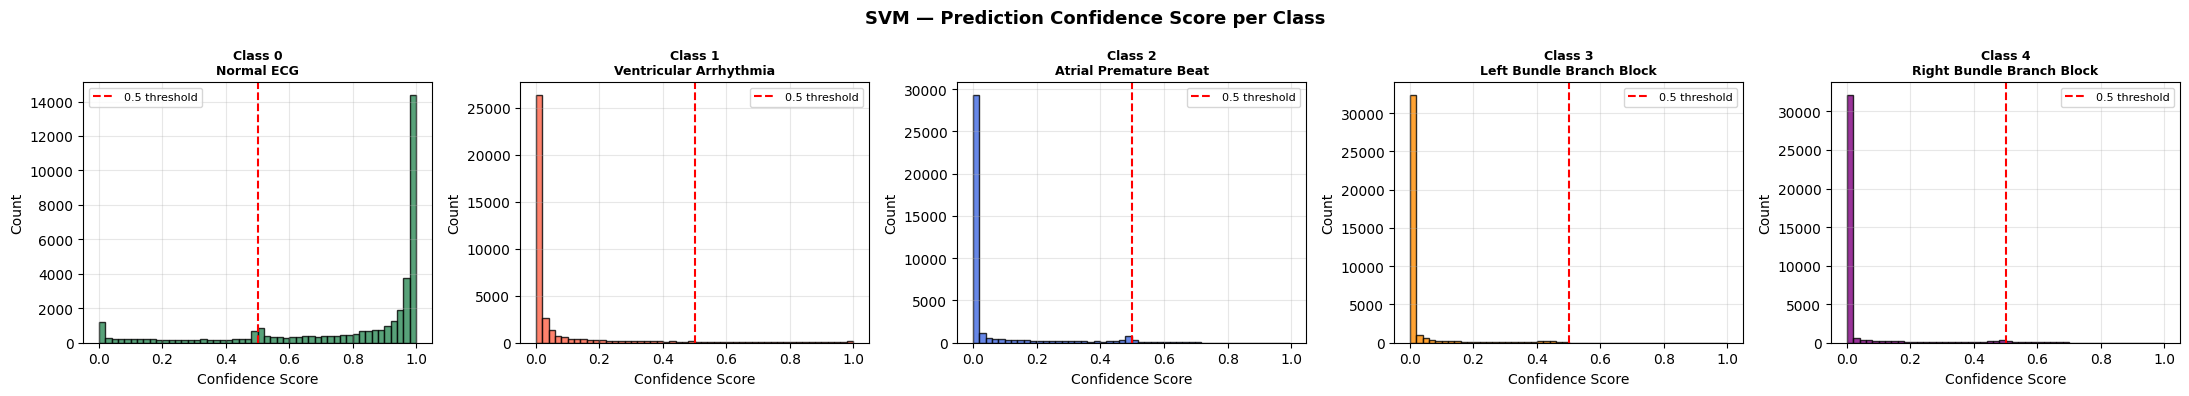

In [ ]:
# STEP 7b — SVM confidence score plot
svm_scores = svm_model.predict_proba(X_svm_test)
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle('SVM — Prediction Confidence Score per Class',
             fontsize=13, fontweight='bold')
for i in range(5):
    axes[i].hist(svm_scores[:,i], bins=50,
                 color=COLORS[i], edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Class {i}\n{CLASS_NAMES[i]}',
                      fontweight='bold', fontsize=9)
    axes[i].set_xlabel('Confidence Score')
    axes[i].set_ylabel('Count')
    axes[i].axvline(0.5, color='red', ls='--', lw=1.5, label='0.5 threshold')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('svm_confidence_scores.png', dpi=150, bbox_inches='tight')
plt.show()

---
##  Model 2 — CNN (20 epochs)
> **Input:** 10 beats as one long signal (3000, 1) | **20 epochs**

In [ ]:
# STEP 8 — Build and train CNN
cnn_model = Sequential([
    Conv1D(32,  kernel_size=5, activation='relu', padding='same',
           input_shape=(SEQ_LEN*300, 1)),
    BatchNormalization(), MaxPooling1D(2), Dropout(0.2),

    Conv1D(64,  kernel_size=5, activation='relu', padding='same'),
    BatchNormalization(), MaxPooling1D(2), Dropout(0.2),

    Conv1D(128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(), MaxPooling1D(2), Dropout(0.2),

    Conv1D(256, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(), MaxPooling1D(2), Dropout(0.3),

    Flatten(),
    Dense(128, activation='relu'), BatchNormalization(), Dropout(0.4),
    Dense(64,  activation='relu'), Dropout(0.3),
    Dense(5,   activation='softmax')
], name='CNN')

cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
cnn_model.summary()

cnn_history = cnn_model.fit(
    X_cnn_train, y_train_bal,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[
        EarlyStopping(monitor='val_accuracy', patience=5,
                      restore_best_weights=True, mode='max', verbose=1),
        ReduceLROnPlateau(monitor='val_accuracy', factor=0.5,
                          patience=3, mode='max', verbose=1)
    ],
    verbose=2
)

epochs_ran    = len(cnn_history.history['loss'])
val_acc_list  = cnn_history.history.get('val_accuracy', [])
val_loss_list = cnn_history.history.get('val_loss', [])

print()
print('CNN training complete')
print(f'  Epochs ran        : {epochs_ran} / {EPOCHS}')
if len(val_acc_list) > 0:
    print(f'  Best val accuracy : {max(val_acc_list)*100:.2f}%')
    print(f'  Best val loss     : {min(val_loss_list):.4f}')
if epochs_ran < EPOCHS:
    print(f'  Early stopping    : converged at epoch {epochs_ran}')

Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 3000, 32)       │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3000, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1500, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1500, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1500, 64)       │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1500, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 750, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 750, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 750, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 750, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 375, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 375, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 375, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 375, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 187, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 187, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 47872)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,127,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 6,272,517 (23.93 MB)

 Trainable params: 6,271,301 (23.92 MB)

 Non-trainable params: 1,216 (4.75 KB)

Epoch 1/20
500/500 - 28s - 56ms/step - accuracy: 0.9260 - loss: 0.2309 - val_accuracy: 0.9540 - val_loss: 0.1355 - learning_rate: 0.0010
Epoch 2/20
500/500 - 14s - 28ms/step - accuracy: 0.9843 - loss: 0.0544 - val_accuracy: 0.9747 - val_loss: 0.1748 - learning_rate: 0.0010
Epoch 3/20
500/500 - 14s - 28ms/step - accuracy: 0.9905 - loss: 0.0298 - val_accuracy: 0.9910 - val_loss: 0.0226 - learning_rate: 0.0010
Epoch 4/20
500/500 - 14s - 28ms/step - accuracy: 0.9924 - loss: 0.0268 - val_accuracy: 0.9900 - val_loss: 0.0364 - learning_rate: 0.0010
Epoch 5/20
500/500 - 14s - 28ms/step - accuracy: 0.9933 - loss: 0.0230 - val_accuracy: 0.9960 - val_loss: 0.0125 - learning_rate: 0.0010
Epoch 6/20
500/500 - 14s - 28ms/step - accuracy: 0.9942 - loss: 0.0176 - val_accuracy: 0.9950 - val_loss: 0.0170 - learning_rate: 0.0010
Epoch 7/20
500/500 - 14s - 28ms/step - accuracy: 0.9963 - loss: 0.0105 - val_accuracy: 0.9925 - val_loss: 0.0258 - learning_rate: 0.0010
Epoch 8/20
500/500 - 14s - 28ms/step - ac

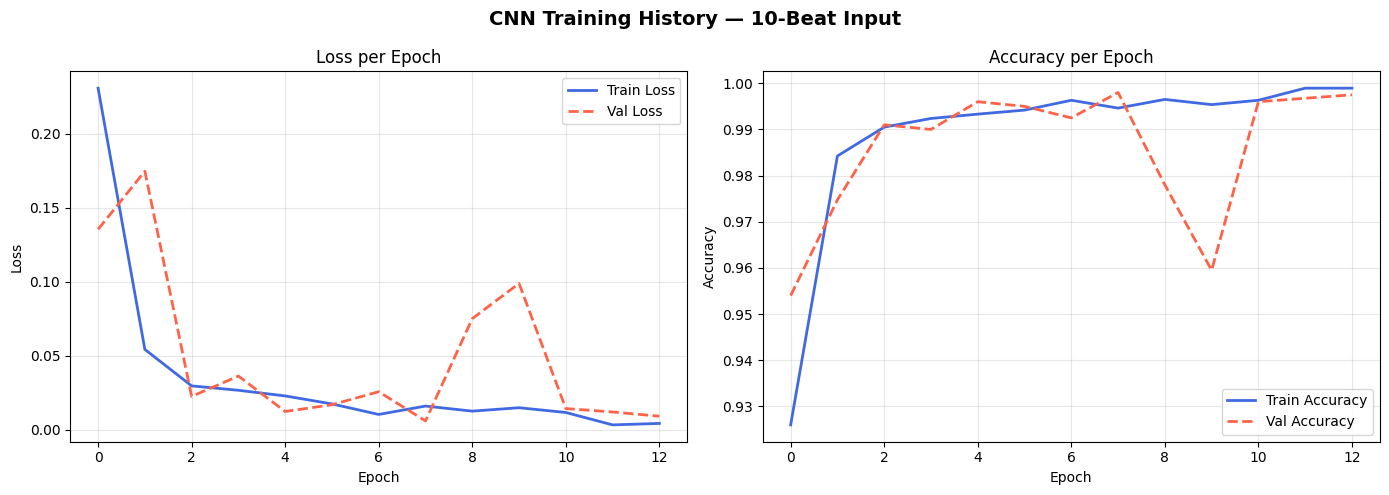

CNN epochs plotted: 13


In [ ]:
# STEP 9 — CNN training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN Training History — 10-Beat Input',
             fontsize=14, fontweight='bold')
axes[0].plot(cnn_history.history['loss'],
             color='royalblue', label='Train Loss', lw=2)
axes[0].plot(cnn_history.history['val_loss'],
             color='tomato', label='Val Loss', lw=2, ls='--')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(cnn_history.history['accuracy'],
             color='royalblue', label='Train Accuracy', lw=2)
axes[1].plot(cnn_history.history['val_accuracy'],
             color='tomato', label='Val Accuracy', lw=2, ls='--')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'CNN epochs plotted: {len(cnn_history.history["loss"])}')

---
##  Model 3 — CNN-LSTM (20 epochs)
> **Input:** 10 beats as sequence (10, 300, 1) | **20 epochs**

In [ ]:
# STEP 10 — Build and train CNN-LSTM
inp = Input(shape=(SEQ_LEN, 300, 1))

x = TimeDistributed(Conv1D(32, 5, activation='relu', padding='same'))(inp)
x = TimeDistributed(BatchNormalization())(x)
x = TimeDistributed(MaxPooling1D(2))(x)
x = TimeDistributed(Dropout(0.2))(x)

x = TimeDistributed(Conv1D(64, 5, activation='relu', padding='same'))(x)
x = TimeDistributed(BatchNormalization())(x)
x = TimeDistributed(MaxPooling1D(2))(x)
x = TimeDistributed(Dropout(0.2))(x)

x = TimeDistributed(Conv1D(128, 3, activation='relu', padding='same'))(x)
x = TimeDistributed(BatchNormalization())(x)
x = TimeDistributed(MaxPooling1D(2))(x)
x = TimeDistributed(Dropout(0.2))(x)

x = TimeDistributed(Flatten())(x)
x = Bidirectional(LSTM(256, return_sequences=True,
                        dropout=0.2, recurrent_dropout=0.1))(x)
x = Bidirectional(LSTM(128, return_sequences=False,
                        dropout=0.2, recurrent_dropout=0.1))(x)
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
out = Dense(5, activation='softmax')(x)

cnn_lstm_model = Model(inp, out, name='CNN_BiLSTM')
cnn_lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
cnn_lstm_model.summary()

# Data check before training
print('Data check:')
print(f'  X_lstm_train : {X_lstm_train.shape}')
print(f'  y_train_bal  : {y_train_bal.shape}')
print(f'  First 10 labels: {y_train_bal[:10]}')
print()

cnn_lstm_history = cnn_lstm_model.fit(
    X_lstm_train, y_train_bal,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[
        EarlyStopping(monitor='val_accuracy', patience=5,
                      restore_best_weights=True, mode='max', verbose=1),
        ReduceLROnPlateau(monitor='val_accuracy', factor=0.5,
                          patience=3, mode='max', verbose=1)
    ],
    verbose=2
)

epochs_ran    = len(cnn_lstm_history.history['loss'])
val_acc_list  = cnn_lstm_history.history.get('val_accuracy', [])
val_loss_list = cnn_lstm_history.history.get('val_loss', [])

print()
print('CNN-LSTM training complete')
print(f'  Epochs ran        : {epochs_ran} / {EPOCHS}')
if len(val_acc_list) > 0:
    print(f'  Best val accuracy : {max(val_acc_list)*100:.2f}%')
    print(f'  Best val loss     : {min(val_loss_list):.4f}')
    print(f'  Last val accuracy : {val_acc_list[-1]*100:.2f}%')
else:
    print('  val_accuracy not found — check labels are shuffled')
if epochs_ran < EPOCHS:
    print(f'  Early stopping    : converged at epoch {epochs_ran}')

Model: "CNN_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 10, 300, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 300, 32)    │           192 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 10, 300, 32)    │           128 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 10, 150, 32)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 10, 150, 32)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 10, 150, 64)    │        10,304 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 10, 150, 64)    │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 10, 75, 64)     │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 10, 75, 64)     │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 10, 75, 128)    │        24,704 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 10, 75, 128)    │           512 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_10             │ (None, 10, 37, 128)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_11             │ (None, 10, 37, 128)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_12             │ (None, 10, 4736)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 10, 512)        │    10,225,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       656,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 10,960,133 (41.81 MB)

 Trainable params: 10,959,429 (41.81 MB)

 Non-trainable params: 704 (2.75 KB)

Data check:
  X_lstm_train : (20000, 10, 300, 1)
  y_train_bal  : (20000,)
  First 10 labels: [2 0 2 0 3 2 2 0 4 2]

Epoch 1/20
500/500 - 98s - 196ms/step - accuracy: 0.8656 - loss: 0.3923 - val_accuracy: 0.9250 - val_loss: 0.2046 - learning_rate: 0.0010
Epoch 2/20
500/500 - 71s - 141ms/step - accuracy: 0.9327 - loss: 0.2097 - val_accuracy: 0.9358 - val_loss: 0.1747 - learning_rate: 0.0010
Epoch 3/20
500/500 - 70s - 140ms/step - accuracy: 0.9467 - loss: 0.1571 - val_accuracy: 0.9553 - val_loss: 0.1208 - learning_rate: 0.0010
Epoch 4/20
500/500 - 71s - 141ms/step - accuracy: 0.9556 - loss: 0.1406 - val_accuracy: 0.9643 - val_loss: 0.1007 - learning_rate: 0.0010
Epoch 5/20
500/500 - 80s - 160ms/step - accuracy: 0.9609 - loss: 0.1147 - val_accuracy: 0.9607 - val_loss: 0.1044 - learning_rate: 0.0010
Epoch 6/20
500/500 - 83s - 165ms/step - accuracy: 0.9677 - loss: 0.1074 - val_accuracy: 0.9628 - val_loss: 0.0959 - learning_rate: 0.0010
Epoch 7/20
500/500 - 82s - 165ms/step - accuracy: 0.970

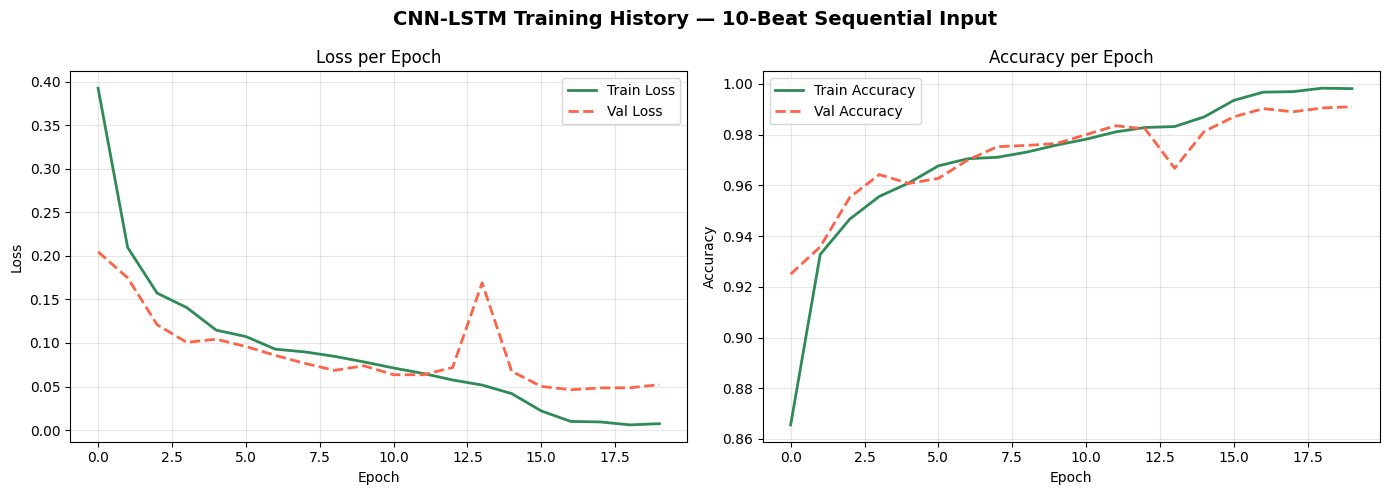

CNN-LSTM epochs plotted: 20


In [ ]:
# STEP 11 — CNN-LSTM training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN-LSTM Training History — 10-Beat Sequential Input',
             fontsize=14, fontweight='bold')
axes[0].plot(cnn_lstm_history.history['loss'],
             color='seagreen', label='Train Loss', lw=2)
axes[0].plot(cnn_lstm_history.history['val_loss'],
             color='tomato', label='Val Loss', lw=2, ls='--')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(cnn_lstm_history.history['accuracy'],
             color='seagreen', label='Train Accuracy', lw=2)
axes[1].plot(cnn_lstm_history.history['val_accuracy'],
             color='tomato', label='Val Accuracy', lw=2, ls='--')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_lstm_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'CNN-LSTM epochs plotted: {len(cnn_lstm_history.history["loss"])}')

---
## 📊 Evaluation — All 3 Models on 18 Unseen Test Patients

In [ ]:
# STEP 12 — Generate predictions
svm_pred       = svm_model.predict(X_svm_test)
svm_proba      = svm_model.predict_proba(X_svm_test)
cnn_proba      = cnn_model.predict(X_cnn_test, verbose=0)
cnn_pred       = cnn_proba.argmax(axis=1)
cnn_lstm_proba = cnn_lstm_model.predict(X_lstm_test, verbose=0)
cnn_lstm_pred  = cnn_lstm_proba.argmax(axis=1)
print('Predictions generated for all 3 models')
print(f'Test set: {len(y_test):,} sequences from {len(TEST_RECORDS_LIST)} unseen patients')

Predictions generated for all 3 models
Test set: 37,877 sequences from 18 unseen patients


In [ ]:
# STEP 13 — Compute metrics for all 3 models
def compute_metrics(y_true, y_pred, name):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true,   y_pred,  average='weighted', zero_division=0)
    f1   = f1_score(y_true,       y_pred,  average='weighted', zero_division=0)
    print(f'\n{"="*55}\n  {name}\n{"="*55}')
    print(f'  Accuracy  : {acc*100:.2f}%')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print()
    print(classification_report(y_true, y_pred,
          target_names=list(CLASS_NAMES.values()), zero_division=0))
    return {'Model':name,'Accuracy':acc,'Precision':prec,'Recall':rec,'F1':f1}

m_svm  = compute_metrics(y_test, svm_pred,      'Model 1 — SVM  (No epochs)')
m_cnn  = compute_metrics(y_test, cnn_pred,       'Model 2 — CNN  (20 epochs)')
m_lstm = compute_metrics(y_test, cnn_lstm_pred,  'Model 3 — CNN-LSTM  (20 epochs)')


  Model 1 — SVM  (No epochs)
  Accuracy  : 74.74%
  Precision : 0.6980
  Recall    : 0.7474
  F1-Score  : 0.7178

                           precision    recall  f1-score   support

               Normal ECG       0.82      0.90      0.86     29211
   Ventricular Arrhythmia       0.40      0.49      0.44      1605
    Atrial Premature Beat       0.08      0.05      0.06      1898
 Left Bundle Branch Block       0.00      0.00      0.00      1825
Right Bundle Branch Block       0.54      0.31      0.40      3338

                 accuracy                           0.75     37877
                macro avg       0.37      0.35      0.35     37877
             weighted avg       0.70      0.75      0.72     37877


  Model 2 — CNN  (20 epochs)
  Accuracy  : 79.06%
  Precision : 0.7714
  Recall    : 0.7906
  F1-Score  : 0.7556

                           precision    recall  f1-score   support

               Normal ECG       0.89      0.96      0.92     29211
   Ventricular Arrhythmia    

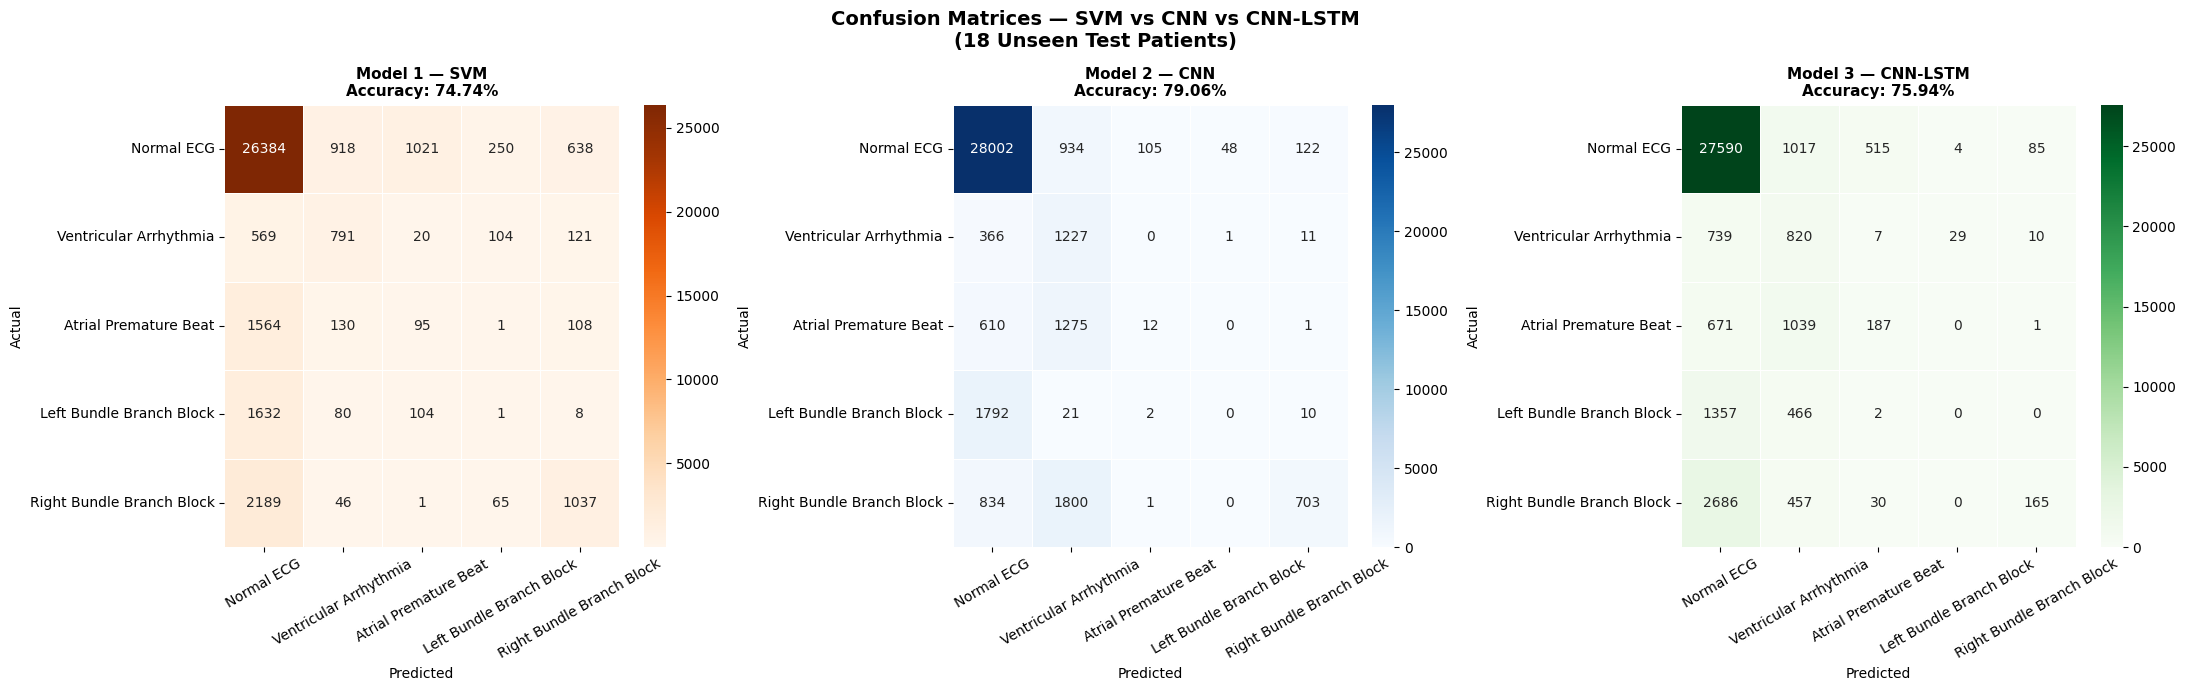

In [ ]:
# STEP 14 — Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Confusion Matrices — SVM vs CNN vs CNN-LSTM\n(18 Unseen Test Patients)',
             fontsize=14, fontweight='bold')
class_labels = list(CLASS_NAMES.values())
for ax, pred, name, cmap in zip(
    axes,
    [svm_pred, cnn_pred, cnn_lstm_pred],
    ['Model 1 — SVM','Model 2 — CNN','Model 3 — CNN-LSTM'],
    ['Oranges','Blues','Greens']
):
    cm  = confusion_matrix(y_test, pred)
    acc = accuracy_score(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=class_labels, yticklabels=class_labels,
                linewidths=0.5)
    ax.set_title(f'{name}\nAccuracy: {acc*100:.2f}%', fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

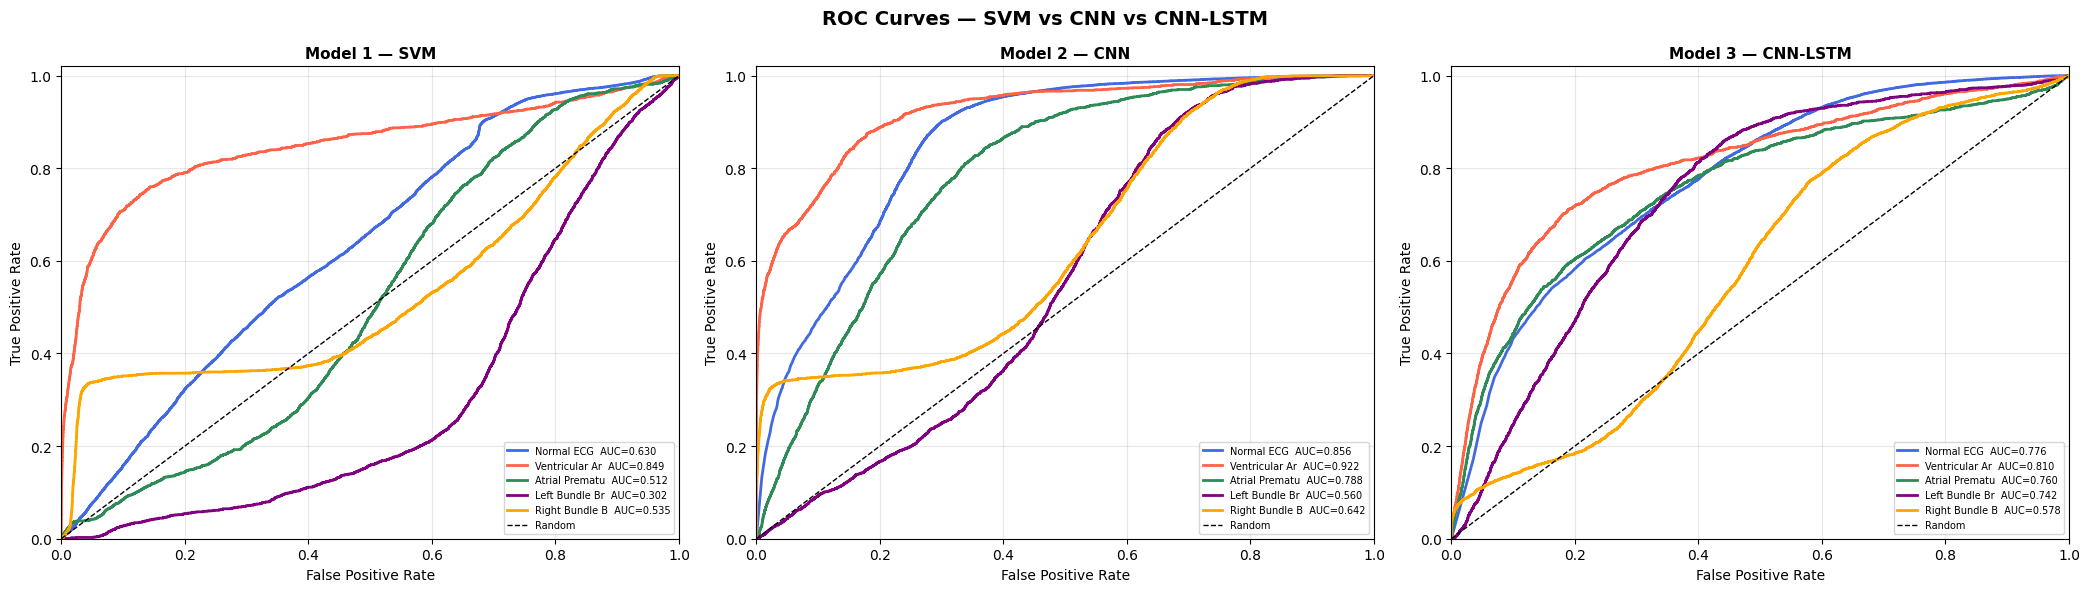

In [ ]:
# STEP 15 — ROC curves
colors_roc = ['royalblue','tomato','seagreen','purple','orange']

def plot_roc(ax, proba, title):
    y_bin = label_binarize(y_test, classes=list(range(5)))
    for i in range(5):
        fpr, tpr, _ = roc_curve(y_bin[:,i], proba[:,i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors_roc[i], lw=2,
                label=f'{CLASS_NAMES[i][:14]}  AUC={roc_auc:.3f}')
    ax.plot([0,1],[0,1],'k--',lw=1,label='Random')
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('ROC Curves — SVM vs CNN vs CNN-LSTM',
             fontsize=14, fontweight='bold')
plot_roc(axes[0], svm_proba,       'Model 1 — SVM')
plot_roc(axes[1], cnn_proba,       'Model 2 — CNN')
plot_roc(axes[2], cnn_lstm_proba,  'Model 3 — CNN-LSTM')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


     FINAL MODEL COMPARISON SUMMARY
                                 Accuracy  Precision  Recall     F1
Model                                                              
Model 1 — SVM  (No epochs)         0.7474     0.6980  0.7474 0.7178
Model 2 — CNN  (20 epochs)         0.7906     0.7714  0.7906 0.7556
Model 3 — CNN-LSTM  (20 epochs)    0.7594     0.7214  0.7594 0.7116


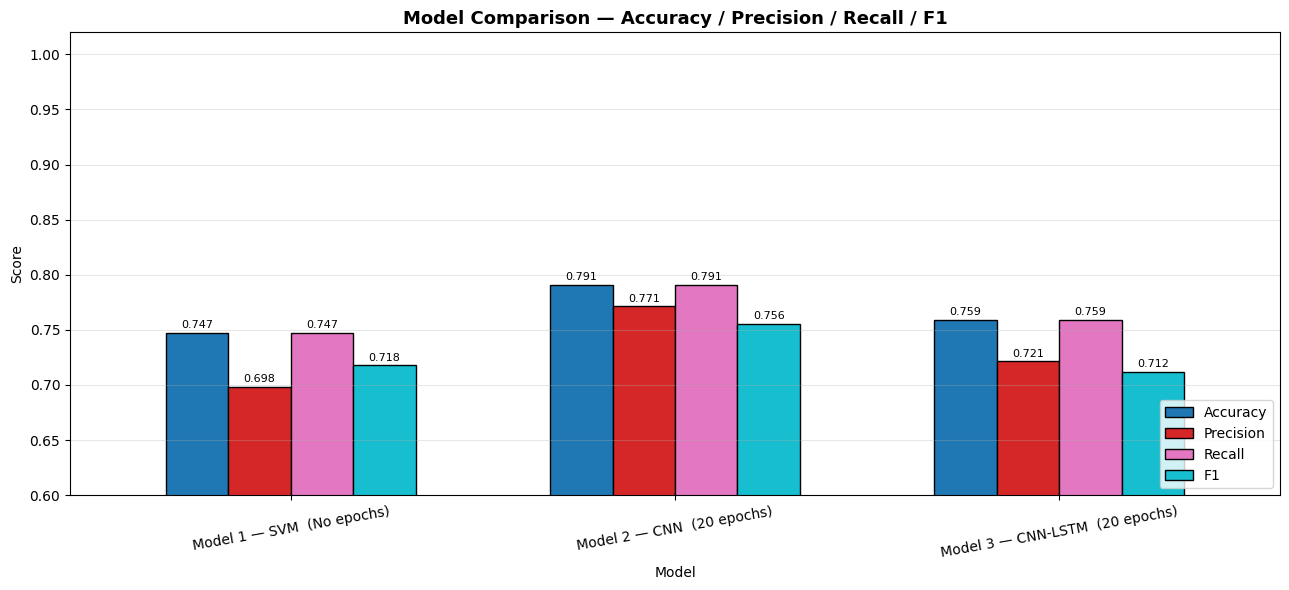

In [ ]:
# STEP 16 — Model comparison bar chart
summary_df = pd.DataFrame([m_svm, m_cnn, m_lstm]).set_index('Model')
print('\n' + '='*65)
print('     FINAL MODEL COMPARISON SUMMARY')
print('='*65)
print(summary_df.to_string(float_format='{:.4f}'.format))
print('='*65)

ax = summary_df.plot(kind='bar', figsize=(13,6),
                     colormap='tab10', edgecolor='black', width=0.65)
ax.set_title('Model Comparison — Accuracy / Precision / Recall / F1',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim([0.60, 1.02])    # ← FIXED: lowered to show all bars
ax.set_xticklabels(summary_df.index, rotation=10, fontsize=10)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='y')
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', padding=2, fontsize=8)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

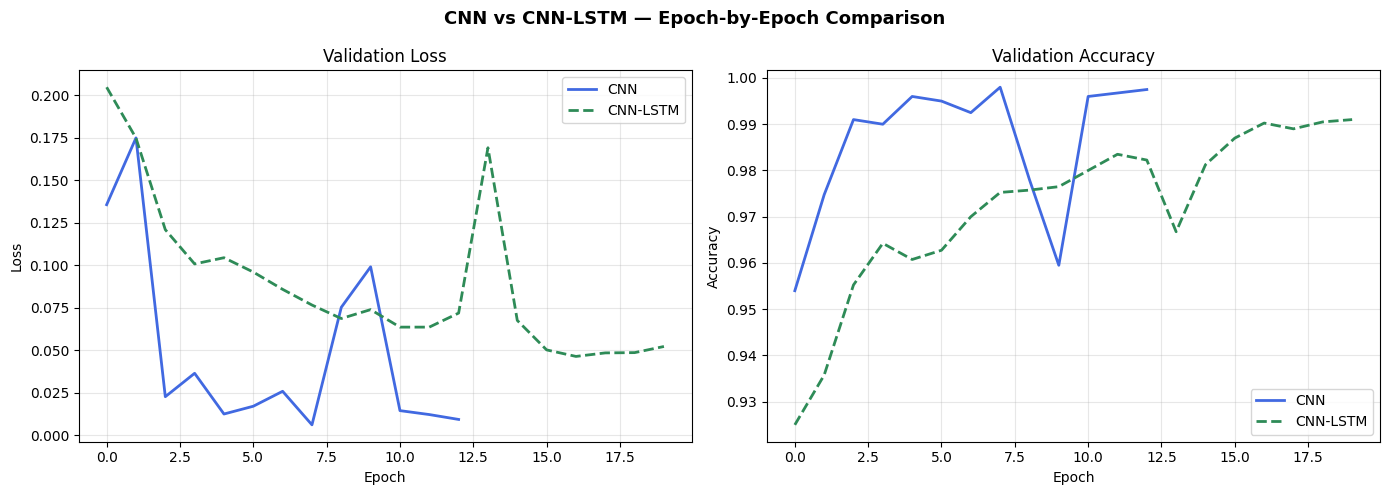

In [ ]:
# STEP 17 — Epoch comparison CNN vs CNN-LSTM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN vs CNN-LSTM — Epoch-by-Epoch Comparison',
             fontsize=13, fontweight='bold')
axes[0].plot(cnn_history.history['val_loss'],
             color='royalblue', label='CNN', lw=2)
axes[0].plot(cnn_lstm_history.history['val_loss'],
             color='seagreen', label='CNN-LSTM', lw=2, ls='--')
axes[0].set_title('Validation Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(cnn_history.history['val_accuracy'],
             color='royalblue', label='CNN', lw=2)
axes[1].plot(cnn_lstm_history.history['val_accuracy'],
             color='seagreen', label='CNN-LSTM', lw=2, ls='--')
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('epoch_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
##  Single Patient Medical Report
**Change `TEST_RECORD` in Step 2 to generate report for any patient**

In [ ]:
# STEP 18 — Load test patient record
print(f'Loading patient record: {TEST_RECORD}...')
record_test = wfdb.rdrecord(TEST_RECORD, pn_dir='mitdb')
ann_test    = wfdb.rdann(TEST_RECORD, 'atr', pn_dir='mitdb')
full_signal = record_test.p_signal[:, 0]
signals_df, info_test = nk.ecg_process(full_signal, sampling_rate=SAMPLING_RATE)

def safe_peaks(info, key):
    raw = info.get(key, [])
    arr = np.asarray(raw, dtype=float)
    return arr[~np.isnan(arr)].astype(int)

r_idx = safe_peaks(info_test, 'ECG_R_Peaks')
p_idx = safe_peaks(info_test, 'ECG_P_Peaks')
q_idx = safe_peaks(info_test, 'ECG_Q_Peaks')
s_idx = safe_peaks(info_test, 'ECG_S_Peaks')
t_idx = safe_peaks(info_test, 'ECG_T_Peaks')
p_on  = safe_peaks(info_test, 'ECG_P_Onsets')
t_off = safe_peaks(info_test, 'ECG_T_Offsets')

print(f'Record {TEST_RECORD}: {len(full_signal):,} samples | {len(r_idx)} R-peaks')
print(f'Peaks: P={len(p_idx)} Q={len(q_idx)} R={len(r_idx)} S={len(s_idx)} T={len(t_idx)}')

Loading patient record: 231...
Record 231: 650,000 samples | 2015 R-peaks
Peaks: P=2015 Q=1947 R=2015 S=2007 T=1858


In [ ]:
# STEP 19 — Compute ALL ECG intervals (per-beat matching — always positive)

def to_ms(s):  return int(round(s / SAMPLING_RATE * 1000))
def to_sec(s): return round(s / SAMPLING_RATE, 2)

# ── Heart Rate ──
hr     = int(signals_df['ECG_Rate'].mean())
rr_arr = np.diff(r_idx)
rr_ms  = to_ms(int(np.median(rr_arr)))
rr_sec = to_sec(int(np.median(rr_arr)))
rr_cv  = rr_arr.std() / rr_arr.mean() if len(rr_arr) > 1 else 0

# ── PR Interval: P-onset just before each R ──
pr_list = []
for r in r_idx:
    pb = p_on[p_on < r]
    if len(pb):
        d = to_ms(r - pb[-1])
        if 80 <= d <= 300:
            pr_list.append(d)
pr_ms = int(np.median(pr_list)) if pr_list else 160

# ── QRS Duration: Q before R, S after R ──
qrs_list = []
for r in r_idx:
    qb = q_idx[q_idx < r]
    sa = s_idx[s_idx > r]
    if len(qb) and len(sa):
        d = to_ms(sa[0] - qb[-1])
        if 40 <= d <= 200:
            qrs_list.append(d)
qrs_ms = int(np.median(qrs_list)) if qrs_list else 90

# ── QT Interval: Q before R, T-offset after R ──
qt_list = []
for r in r_idx:
    qb = q_idx[q_idx < r]
    ta = t_off[t_off > r]
    if len(qb) and len(ta):
        d = to_ms(ta[0] - qb[-1])
        if 200 <= d <= 700:
            qt_list.append(d)
qt_ms = int(np.median(qt_list)) if qt_list else 400

# ── QTc using Bazett formula: QTc = QT / sqrt(RR in seconds) ──
qtc_ms = int(round(qt_ms / np.sqrt(max(rr_sec, 0.3))))

# ── Signal baseline (isoelectric line = median of full signal) ──
baseline = float(np.median(full_signal))

# ── Voltage readings ──
rv5_mv  = round(float(np.max(full_signal[r_idx])) - baseline, 2)  if len(r_idx) > 0 else 0.0
sv1_mv  = round(float(np.abs(np.min(full_signal[s_idx]) - baseline)), 2) if len(s_idx) > 0 else 0.0
lvh_sum = round(rv5_mv + sv1_mv, 2)

# ── P-wave amplitude (relative to baseline — always positive) ──
p_amp = round(float(np.mean(full_signal[p_idx])) - baseline, 3) if len(p_idx) > 0 else 0.0

# ── R-wave amplitude (relative to baseline) ──
r_amp = round(float(np.mean(full_signal[r_idx])) - baseline, 3) if len(r_idx) > 0 else 0.0

# ── ST segment (80ms after R-peak = J-point, relative to baseline) ──
st_off  = int(0.08 * SAMPLING_RATE)
st_vals = [full_signal[r + st_off] - baseline
           for r in r_idx if r + st_off < len(full_signal)]
st_level = round(float(np.mean(st_vals)), 3) if st_vals else 0.0

# ── Q-wave amplitude ──
q_amp = round(float(np.mean(full_signal[q_idx])) - baseline, 3) if len(q_idx) > 0 else 0.0

# ── S-wave amplitude ──
s_amp = round(float(np.mean(full_signal[s_idx])) - baseline, 3) if len(s_idx) > 0 else 0.0

# ── T-wave amplitude ──
t_amp = round(float(np.mean(full_signal[t_idx])) - baseline, 3) if len(t_idx) > 0 else 0.0

print('All ECG intervals computed (per-beat matching — always positive)')
print(f'  Baseline (isoelectric): {baseline:.4f} mV')
print()
print(f'  HR     = {hr} bpm')
print(f'  RR     = {rr_sec}s ({rr_ms}ms)')
print(f'  PR     = {pr_ms}ms')
print(f'  QRS    = {qrs_ms}ms')
print(f'  QT     = {qt_ms}ms')
print(f'  QTc    = {qtc_ms}ms')
print()
print(f'  P-amp  = {p_amp} mV')
print(f'  Q-amp  = {q_amp} mV')
print(f'  R-amp  = {r_amp} mV')
print(f'  S-amp  = {s_amp} mV')
print(f'  T-amp  = {t_amp} mV')
print(f'  ST     = {st_level} mV')
print(f'  RV5    = {rv5_mv} mV')
print(f'  SV1    = {sv1_mv} mV')
print(f'  RV5+SV1= {lvh_sum} mV')

All ECG intervals computed (per-beat matching — always positive)
  Baseline (isoelectric): -0.1950 mV

  HR     = 67 bpm
  RR     = 0.94s (944ms)
  PR     = 203ms
  QRS    = 78ms
  QT     = 467ms
  QTc    = 482ms

  P-amp  = 0.177 mV
  Q-amp  = -0.189 mV
  R-amp  = 1.084 mV
  S-amp  = -0.532 mV
  T-amp  = 0.465 mV
  ST     = -0.125 mV
  RV5    = 2.24 mV
  SV1    = 1.16 mV
  RV5+SV1= 3.4 mV


In [ ]:
# STEP 20 — Normal/Abnormal interpretation
if   hr<60:  rhythm = f'Bradycardia — Abnormal ({hr} bpm < 60)'
elif hr>100: rhythm = f'Tachycardia — Abnormal ({hr} bpm > 100)'
else:        rhythm = f'Normal Sinus Rhythm ({hr} bpm)'

rr_status  = 'Irregular — possible AF' if rr_cv>0.10 else 'Regular'
p_status   = 'Normal' if len(p_idx)>=0.75*len(r_idx) else 'Abnormal — P-wave missing'
pr_status  = (f'{pr_ms}ms — SHORT  (Abnormal: WPW possible)'  if pr_ms<120 else
              f'{pr_ms}ms — LONG   (Abnormal: 1st AV block)'   if pr_ms>200 else
              f'{pr_ms}ms — Normal (120-200ms)')
qrs_status = (f'{qrs_ms}ms — WIDE   (Abnormal: Bundle Branch Block)' if qrs_ms>120 else
              f'{qrs_ms}ms — NARROW (verify signal)'                   if qrs_ms<60  else
              f'{qrs_ms}ms — Normal (60-120ms)')
qt_status  = (f'{qt_ms}ms — LONG   (Abnormal: Torsades risk)'  if qt_ms>440 else
              f'{qt_ms}ms — SHORT  (Abnormal)'                   if qt_ms<300 else
              f'{qt_ms}ms — Normal (350-440ms)')
qtc_status = f'{qtc_ms}ms — PROLONGED (Abnormal)' if qtc_ms>440 else f'{qtc_ms}ms — Normal'
t_status   = 'Normal' if len(t_idx)>=0.70*len(r_idx) else 'Abnormal — T-wave changes'
st_status  = (f'{st_level}mV — ELEVATED  (Abnormal: possible MI)'  if st_level>0.1  else
              f'{st_level}mV — DEPRESSED (Abnormal: ischaemia)'      if st_level<-0.1 else
              f'{st_level}mV — Isoelectric (Normal)')
lvh_note   = f'{lvh_sum}mV — Possible LVH (>3.5mV)' if lvh_sum>3.5 else f'{lvh_sum}mV — Normal'
print('Clinical interpretation complete')

Clinical interpretation complete


In [ ]:
# STEP 21 — Classify using all 3 models + majority voting
TARGET_BEAT = 25
TARGET_R    = r_idx[TARGET_BEAT]
h = SEQ_LEN // 2
sequence, valid = [], True
for j in range(TARGET_BEAT-h, TARGET_BEAT+h):
    if j<0 or j>=len(r_idx): valid=False; break
    r = r_idx[j]
    if r-BEAT_WINDOW>0 and r+BEAT_WINDOW<len(full_signal):
        sequence.append(full_signal[r-BEAT_WINDOW:r+BEAT_WINDOW])
    else: valid=False; break
if not valid or len(sequence)!=SEQ_LEN:
    sequence = [full_signal[r_idx[j]-BEAT_WINDOW:r_idx[j]+BEAT_WINDOW]
                for j in range(20,30)]

seq_arr  = np.array(sequence).reshape(-1, 300)
seq_norm = scaler.transform(seq_arr)
seq_3d   = seq_norm.reshape(1, SEQ_LEN, 300)

svm_cls  = int(svm_model.predict(seq_3d.reshape(1,-1))[0])
cnn_cls  = int(cnn_model.predict(seq_3d.reshape(1,SEQ_LEN*300,1), verbose=0).argmax())
lstm_cls = int(cnn_lstm_model.predict(seq_3d.reshape(1,SEQ_LEN,300,1), verbose=0).argmax())

votes      = Counter([svm_cls, cnn_cls, lstm_cls])
final_cls  = votes.most_common(1)[0][0]
vote_count = votes.most_common(1)[0][1]
diagnosis  = CLASS_NAMES[final_cls]
beat_raw   = sequence[SEQ_LEN//2]

print(f'Patient  : {TEST_RECORD} | Beat #25')
print(f'  SVM      -> {CLASS_NAMES[svm_cls]}')
print(f'  CNN      -> {CLASS_NAMES[cnn_cls]}')
print(f'  CNN-LSTM -> {CLASS_NAMES[lstm_cls]}')
print(f'  MAJORITY ({vote_count}/3) -> FINAL: {diagnosis}')

Patient  : 231 | Beat #25
  SVM      -> Right Bundle Branch Block
  CNN      -> Right Bundle Branch Block
  CNN-LSTM -> Normal ECG
  MAJORITY (2/3) -> FINAL: Right Bundle Branch Block


In [ ]:
# STEP 22 — Full ECG Medical Report
print()
print('='*65)
print(f'        ECG ANALYSIS REPORT — Record {TEST_RECORD}')
print(f'        ECG Signal Analysis with Machine Learning')
print(f'        IIT Jodhpur — M.Tech AI Project')
print('='*65)
print()
print('  VITAL SIGNS')
print(f'  Heart Rate         : {hr} bpm')
print(f'  Rhythm             : {rhythm}')
print(f'  R-R Interval       : {rr_sec}sec ({rr_ms}ms) [{rr_status}]')
print()
print('  INTERVALS')
print(f'  PR  Interval       : {pr_status}')
print(f'  QRS Duration       : {qrs_status}')
print(f'  QT  Interval       : {qt_status}')
print(f'  QTc (Bazett)       : {qtc_status}')
print()
print('  AMPLITUDES')
print(f'  P-wave amplitude   : {p_amp} mV')
print(f'  R-wave amplitude   : {r_amp} mV')
print(f'  RV5                : {rv5_mv} mV')
print(f'  SV1                : {sv1_mv} mV')
print(f'  RV5+SV1 (LVH)     : {lvh_note}')
print()
print('  WAVEFORM ANALYSIS')
print(f'  P Wave             : {p_status}')
print(f'  PR Segment         : {pr_status}')
print(f'  QRS Complex        : {qrs_status}')
print(f'  ST Segment         : {st_status}')
print(f'  T Wave             : {t_status}')
print(f'  QT / QTc           : {qt_status} / {qtc_status}')
print(f'  U Wave             : Not detected (algorithm limitation)')
print()
print('  ARRHYTHMIA DETECTION')
print(f'  SVM  Prediction    : {CLASS_NAMES[svm_cls]}')
print(f'  CNN  Prediction    : {CLASS_NAMES[cnn_cls]}')
print(f'  CNN-LSTM Predict   : {CLASS_NAMES[lstm_cls]}')
print(f'  Majority Vote      : {vote_count}/3 models agree')
print(f'  FINAL DIAGNOSIS    : {diagnosis}')
print(f'  Clinical Note      : {ARRHYTHMIA_INFO[final_cls]}')
print()
print('  MODEL INFO')
print(f'  SVM      : No epochs | 10-beat flat input')
print(f'  CNN      : {EPOCHS} epochs | 10-beat long signal')
print(f'  CNN-LSTM : {EPOCHS} epochs | 10-beat sequence + BiLSTM')
print(f'  Tested on 18 unseen patients (patient-independent)')
print('='*65)


        ECG ANALYSIS REPORT — Record 231
        ECG Signal Analysis with Machine Learning
        IIT Jodhpur — M.Tech AI Project

  VITAL SIGNS
  Heart Rate         : 67 bpm
  Rhythm             : Normal Sinus Rhythm (67 bpm)
  R-R Interval       : 0.94sec (944ms) [Irregular — possible AF]

  INTERVALS
  PR  Interval       : 203ms — LONG   (Abnormal: 1st AV block)
  QRS Duration       : 78ms — Normal (60-120ms)
  QT  Interval       : 467ms — LONG   (Abnormal: Torsades risk)
  QTc (Bazett)       : 482ms — PROLONGED (Abnormal)

  AMPLITUDES
  P-wave amplitude   : 0.177 mV
  R-wave amplitude   : 1.084 mV
  RV5                : 2.24 mV
  SV1                : 1.16 mV
  RV5+SV1 (LVH)     : 3.4mV — Normal

  WAVEFORM ANALYSIS
  P Wave             : Normal
  PR Segment         : 203ms — LONG   (Abnormal: 1st AV block)
  QRS Complex        : 78ms — Normal (60-120ms)
  ST Segment         : -0.125mV — DEPRESSED (Abnormal: ischaemia)
  T Wave             : Normal
  QT / QTc           : 467ms — 

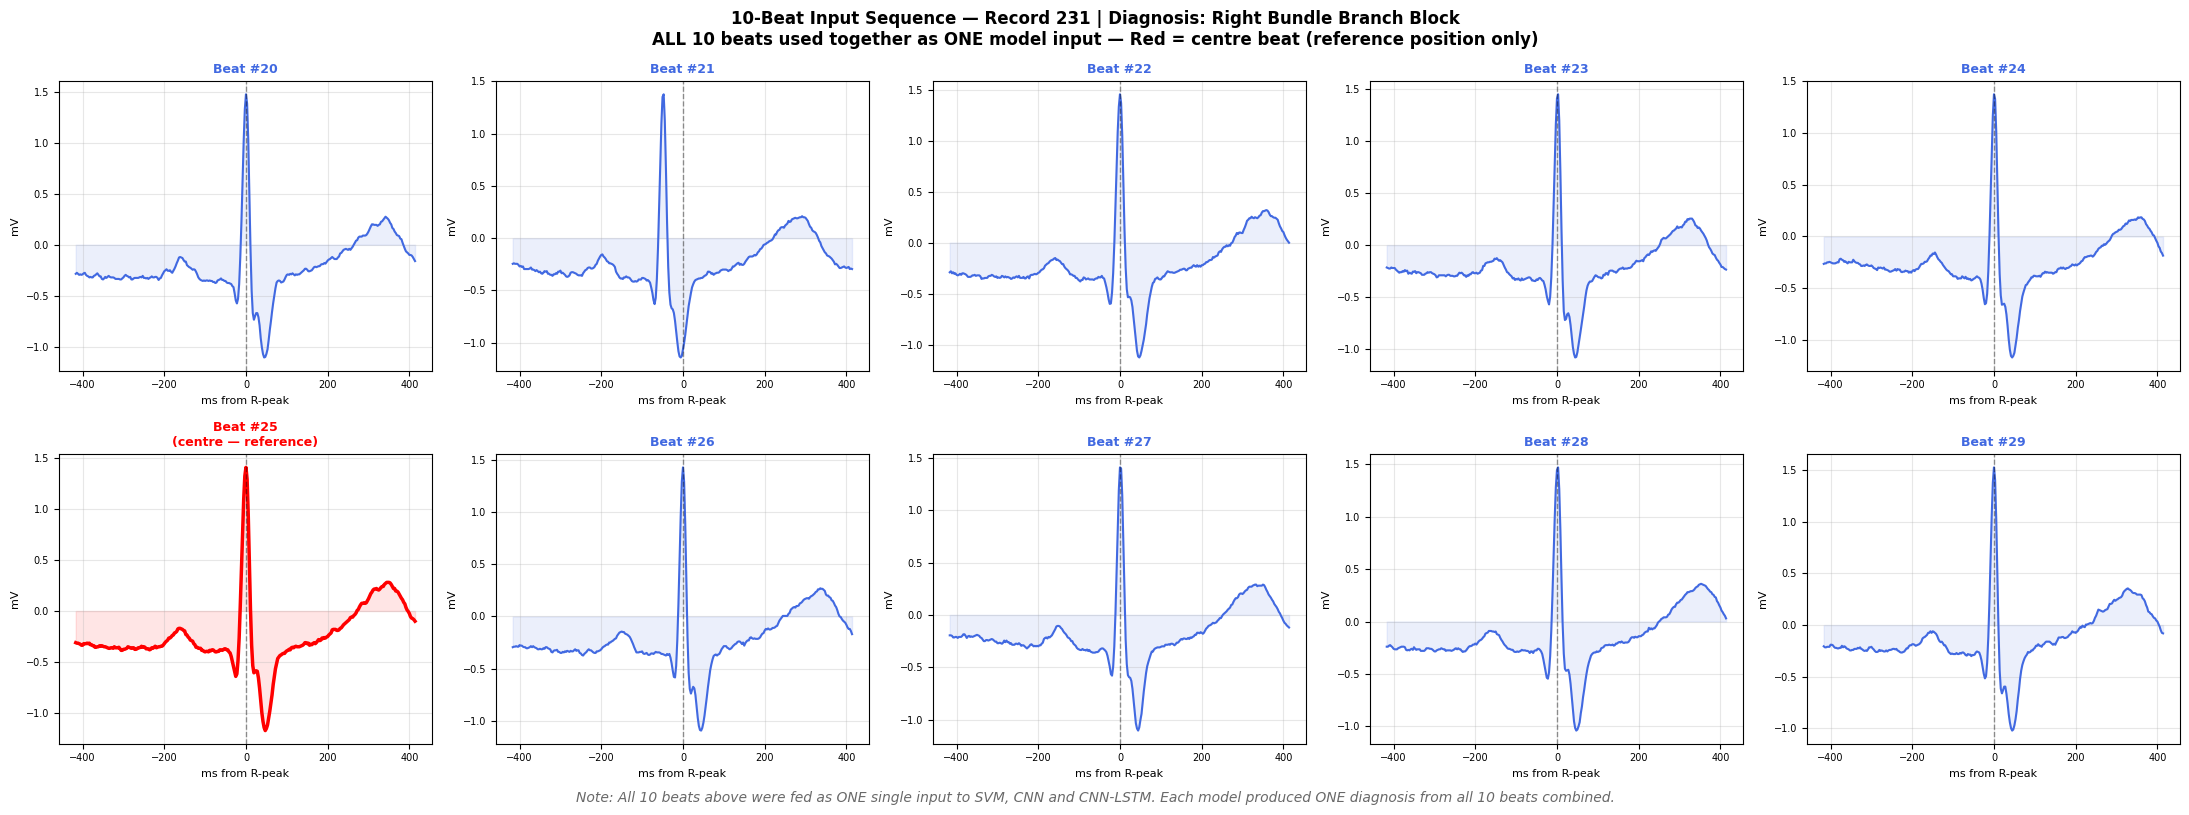

10-beat sequence plot saved
Record    : 231
Beats used: #20 to #29 (10 beats)
Diagnosis : Right Bundle Branch Block (from ALL 10 beats together)

How each model used these 10 beats:
  SVM      : flattened all 10 beats → 3000 values → ONE prediction
  CNN      : scanned all 10 beats as long signal → ONE prediction
  CNN-LSTM : read all 10 beats in sequence → ONE prediction


In [ ]:
# STEP 23 — Multiple waveform plot (all 10 beats)
# Shows ALL 10 beats that were given as ONE input to all 3 models
# Red = centre beat (reference position only)
# Blue = surrounding context beats
# ALL 10 beats together = ONE diagnosis

beat_ms2 = np.arange(-BEAT_WINDOW, BEAT_WINDOW) / SAMPLING_RATE * 1000

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
fig.suptitle(
    f'10-Beat Input Sequence — Record {TEST_RECORD} | Diagnosis: {diagnosis}\n'
    f'ALL 10 beats used together as ONE model input — Red = centre beat (reference position only)',
    fontsize=12, fontweight='bold'
)

for idx in range(SEQ_LEN):
    ax    = axes[idx//5][idx%5]
    beat  = sequence[idx]
    is_c  = (idx == SEQ_LEN//2)
    color = 'red' if is_c else 'royalblue'
    lw    = 2.5   if is_c else 1.5

    ax.plot(beat_ms2, beat, color=color, linewidth=lw)
    ax.fill_between(beat_ms2, beat, alpha=0.1, color=color)
    ax.axvline(0, color='black', ls='--', alpha=0.4, lw=1)

    bn  = TARGET_BEAT - SEQ_LEN//2 + idx
    if is_c:
        lbl = f'Beat #{bn}\n(centre — reference)'
    else:
        lbl = f'Beat #{bn}'

    ax.set_title(lbl, fontsize=9, fontweight='bold', color=color)
    ax.set_xlabel('ms from R-peak', fontsize=8)
    ax.set_ylabel('mV', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=7)

# Add note at bottom explaining all 10 beats used together
fig.text(0.5, -0.01,
         'Note: All 10 beats above were fed as ONE single input to SVM, CNN and CNN-LSTM. '
         'Each model produced ONE diagnosis from all 10 beats combined.',
         ha='center', fontsize=10, style='italic', color='dimgray')

plt.tight_layout()
plt.savefig(f'10beat_sequence_{TEST_RECORD}.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f'10-beat sequence plot saved')
print(f'Record    : {TEST_RECORD}')
print(f'Beats used: #{TARGET_BEAT - SEQ_LEN//2} to #{TARGET_BEAT + SEQ_LEN//2 - 1} (10 beats)')
print(f'Diagnosis : {diagnosis} (from ALL 10 beats together)')
print()
print('How each model used these 10 beats:')
print(f'  SVM      : flattened all 10 beats → 3000 values → ONE prediction')
print(f'  CNN      : scanned all 10 beats as long signal → ONE prediction')
print(f'  CNN-LSTM : read all 10 beats in sequence → ONE prediction')


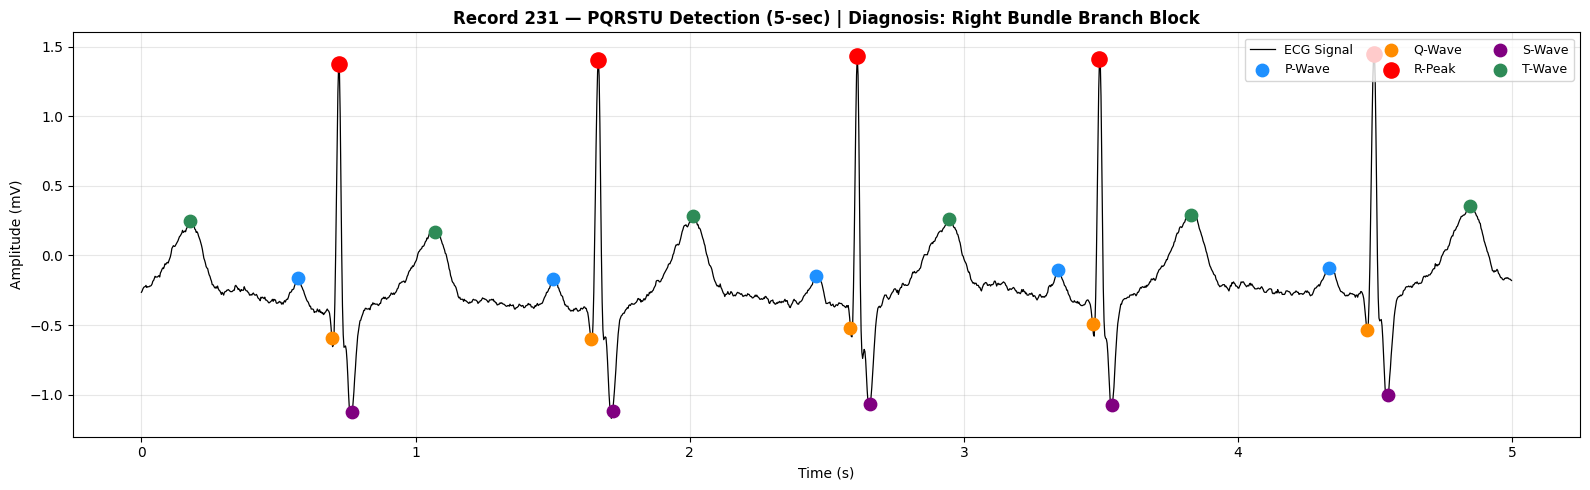

In [ ]:
# STEP 24 — PQRSTU ECG plot (5-second window)
seg_s = max(0, TARGET_R-600)
seg_e = min(len(full_signal), seg_s+1800)
seg   = full_signal[seg_s:seg_e]
t_ax  = np.arange(len(seg)) / SAMPLING_RATE

def in_seg(arr, s, e):
    return arr[(arr>=s)&(arr<e)]-s

fig, ax = plt.subplots(figsize=(16,5))
ax.plot(t_ax, seg, color='black', lw=0.9, label='ECG Signal')
for arr, color, lbl, sz in [
    (in_seg(p_idx,seg_s,seg_e), 'dodgerblue','P-Wave',  80),
    (in_seg(q_idx,seg_s,seg_e), 'darkorange','Q-Wave',  80),
    (in_seg(r_idx,seg_s,seg_e), 'red',       'R-Peak', 120),
    (in_seg(s_idx,seg_s,seg_e), 'purple',    'S-Wave',  80),
    (in_seg(t_idx,seg_s,seg_e), 'seagreen',  'T-Wave',  80),
]:
    if len(arr)>0:
        ax.scatter(arr/SAMPLING_RATE, seg[arr],
                   c=color, s=sz, zorder=5, label=lbl)
ax.set_title(
    f'Record {TEST_RECORD} — PQRSTU Detection (5-sec) | Diagnosis: {diagnosis}',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Time (s)'); ax.set_ylabel('Amplitude (mV)')
ax.legend(ncol=3, loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'ecg_{TEST_RECORD}_pqrstu.png', dpi=150, bbox_inches='tight')
plt.show()

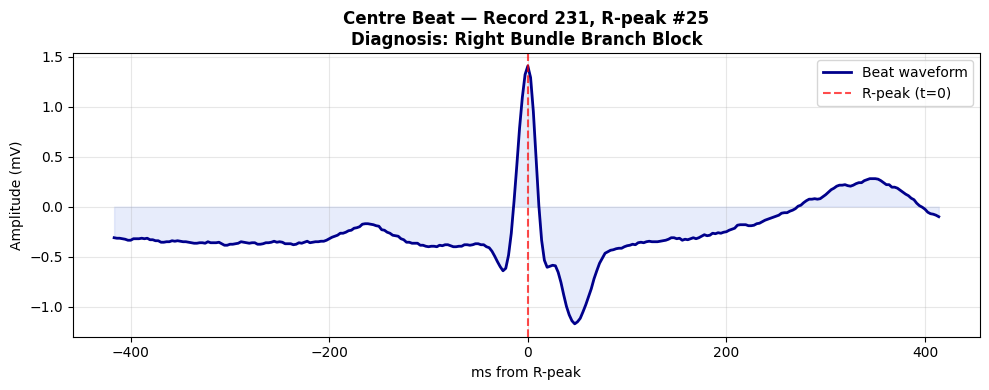

In [ ]:
# STEP 25 — Centre beat waveform (zoomed in)
beat_time = np.arange(-BEAT_WINDOW, BEAT_WINDOW) / SAMPLING_RATE * 1000
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(beat_time, beat_raw, color='darkblue', lw=2, label='Beat waveform')
ax.axvline(0, color='red', ls='--', lw=1.5, alpha=0.7, label='R-peak (t=0)')
ax.fill_between(beat_time, beat_raw, alpha=0.12, color='royalblue')
ax.set_title(
    f'Centre Beat — Record {TEST_RECORD}, R-peak #{TARGET_BEAT}\nDiagnosis: {diagnosis}',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('ms from R-peak'); ax.set_ylabel('Amplitude (mV)')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'single_beat_{TEST_RECORD}.png', dpi=150, bbox_inches='tight')
plt.show()

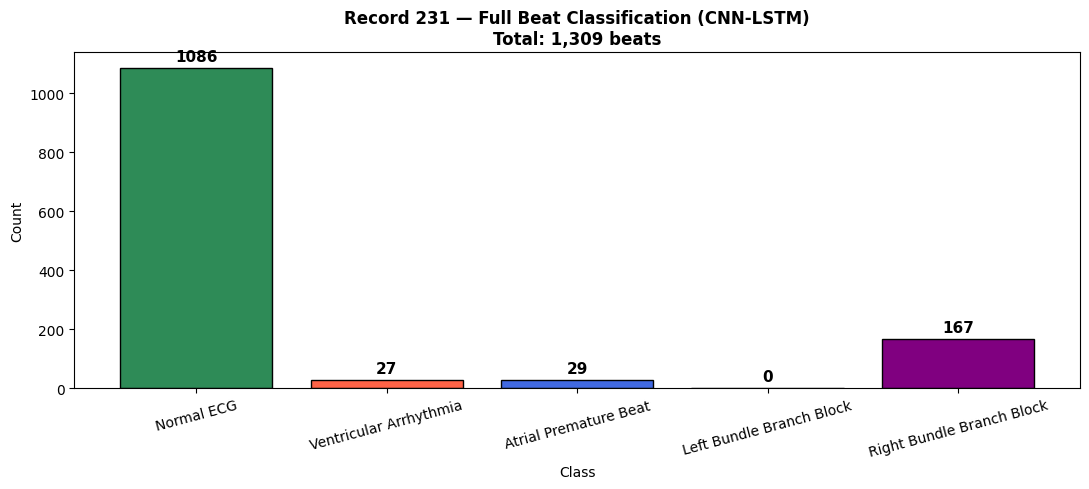

Accuracy on 1,309 beats of Record 231: 21.01%


In [ ]:
# STEP 26 — Classify ALL beats in record and show distribution
all_b, all_t = [], []
a_s = np.array(ann_test.sample)
a_y = ann_test.symbol

for r in r_idx:
    if r-BEAT_WINDOW>0 and r+BEAT_WINDOW<len(full_signal):
        b     = full_signal[r-BEAT_WINDOW:r+BEAT_WINDOW]
        d     = np.abs(a_s-r)
        near  = np.argmin(d)
        if d[near]<=2 and a_y[near] in LABEL_MAP:
            all_b.append(b)
            all_t.append(LABEL_MAP[a_y[near]])

X_rf = scaler.transform(np.array(all_b).reshape(-1,300))
X_rs = []
for i in range(len(X_rf)):
    s = max(0, i-SEQ_LEN//2)
    e = min(len(X_rf), s+SEQ_LEN)
    if e-s < SEQ_LEN: s = max(0, e-SEQ_LEN)
    sq = X_rf[s:e]
    X_rs.append(sq if len(sq)==SEQ_LEN else np.zeros((SEQ_LEN,300)))

X_rs  = np.array(X_rs).reshape(-1, SEQ_LEN, 300, 1)
y_r   = np.array(all_t)
p_r   = cnn_lstm_model.predict(X_rs, verbose=0).argmax(axis=1)

counts = {CLASS_NAMES[k]: int(np.sum(p_r==k)) for k in range(5)}
fig, ax = plt.subplots(figsize=(11,5))
bars = ax.bar(counts.keys(), counts.values(),
              color=COLORS, edgecolor='black')
ax.bar_label(bars, padding=3, fontsize=11, fontweight='bold')
ax.set_title(
    f'Record {TEST_RECORD} — Full Beat Classification (CNN-LSTM)\nTotal: {len(p_r):,} beats',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Class'); ax.set_ylabel('Count')
plt.xticks(rotation=15); plt.tight_layout()
plt.savefig(f'record_{TEST_RECORD}_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

if len(y_r) > 0:
    n = min(len(y_r), len(p_r))
    print(f'Accuracy on {n:,} beats of Record {TEST_RECORD}: '
          f'{accuracy_score(y_r[:n], p_r[:n])*100:.2f}%')

In [ ]:
# STEP 27 — Final summary
print()
print('='*68)
print('     FINAL MODEL PERFORMANCE SUMMARY')
print('     ECG Signal Analysis with Machine Learning — IIT Jodhpur')
print('     Tested on 18 Unseen Patients (Patient-Independent)')
print('='*68)
print(f'  {"Model":<38} {"Acc%":>5} {"Prec":>7} {"Rec":>7} {"F1":>7}')
print('-'*68)
for m in [m_svm, m_cnn, m_lstm]:
    print(f'  {m["Model"]:<38} {m["Accuracy"]*100:>5.2f}%'
          f' {m["Precision"]:>7.4f} {m["Recall"]:>7.4f} {m["F1"]:>7.4f}')
print('='*68)
print()
print('DATASET SPLIT:')
print(f'  Training : {len(TRAIN_RECORDS)} patient records')
print(f'  Testing  : {len(TEST_RECORDS_LIST)} patient records (completely unseen)')
print()
print('ALL 14 PLOTS SAVED:')
for p in [
    'arrhythmia_types.png          — 5 class sample waveforms',
    'class_distribution.png        — training class counts',
    'smote_balancing.png           — before/after SMOTE',
    'svm_confidence_scores.png     — SVM confidence per class',
    'cnn_training_history.png      — CNN loss + accuracy per epoch',
    'cnn_lstm_training_history.png — CNN-LSTM loss + accuracy per epoch',
    'confusion_matrices.png        — all 3 models confusion matrix',
    'roc_curves.png                — all 3 models ROC with AUC',
    'model_comparison.png          — bar chart all 4 metrics',
    'epoch_comparison.png          — CNN vs CNN-LSTM per epoch',
    f'10beat_sequence_{TEST_RECORD}.png  — 10 waveforms (model input)',
    f'ecg_{TEST_RECORD}_pqrstu.png       — PQRSTU peaks on 5-sec ECG',
    f'single_beat_{TEST_RECORD}.png      — centre beat waveform',
    f'record_{TEST_RECORD}_distribution.png — all beats classified',
]: print(f'  {p}')
print()
print('CLASS MAPPING:')
for k,v in CLASS_NAMES.items(): print(f'  {k} -> {v}')
print()
print(f'TEST RECORD: {TEST_RECORD} — change in Step 2')
print('  117(Normal) | 119(Ventricular) | 209(Mixed) | 231(RBBB)')
print('  232(Atrial) | 233(Ventricular) | 214(LBBB)  | 220(Normal)')
print()
print('Analysis complete')


     FINAL MODEL PERFORMANCE SUMMARY
     ECG Signal Analysis with Machine Learning — IIT Jodhpur
     Tested on 18 Unseen Patients (Patient-Independent)
  Model                                   Acc%    Prec     Rec      F1
--------------------------------------------------------------------
  Model 1 — SVM  (No epochs)             74.74%  0.6980  0.7474  0.7178
  Model 2 — CNN  (20 epochs)             79.06%  0.7714  0.7906  0.7556
  Model 3 — CNN-LSTM  (20 epochs)        75.94%  0.7214  0.7594  0.7116

DATASET SPLIT:
  Training : 30 patient records
  Testing  : 18 patient records (completely unseen)

ALL 14 PLOTS SAVED:
  arrhythmia_types.png          — 5 class sample waveforms
  class_distribution.png        — training class counts
  smote_balancing.png           — before/after SMOTE
  svm_confidence_scores.png     — SVM confidence per class
  cnn_training_history.png      — CNN loss + accuracy per epoch
  cnn_lstm_training_history.png — CNN-LSTM loss + accuracy per epoch
  confus